# Exploring generative music with transformers — Apple Silicon (M5)

Runs locally on macOS with the MPS GPU backend. Adapted from the Colab version — no Drive, no CUDA, no Google Colab-specific APIs.

## Before running, set up the environment

```bash
python3 -m venv maestro-env
source maestro-env/bin/activate
pip install torch transformers miditok symusic miditoolkit tqdm matplotlib numpy scipy
pip install jupyter ipywidgets
pip install pretty_midi pyfluidsynth midi2audio

brew install fluidsynth
mkdir -p ~/soundfonts
curl -L -o ~/soundfonts/FluidR3_GM.sf2 \
  https://ftp.osuosl.org/pub/musescore-soundfonts/FluidR3_GM.sf2

jupyter notebook
```

## Before kicking off training

- Plug in power — macOS throttles GPU on battery
- Run `caffeinate -i &` in a terminal to prevent sleep
- Close Chrome / Slack / Spotify — they compete for unified memory

## 1. Setup — paths, device, imports

In [2]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
from pathlib import Path

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"PyTorch: {torch.__version__}")
print(f"Device : {DEVICE}")

PROJECT_DIR = Path.cwd()
MIDI_DIR    = PROJECT_DIR / "midi"
TOKEN_DIR   = PROJECT_DIR / "tokens"
CKPT_DIR    = PROJECT_DIR / "checkpoints_25m"
SAMPLE_DIR  = PROJECT_DIR / "samples"

for d in (MIDI_DIR, TOKEN_DIR, CKPT_DIR, SAMPLE_DIR):
    d.mkdir(exist_ok=True)

print(f"\nProject root : {PROJECT_DIR}")
print(f"MIDI input   : {MIDI_DIR}  ({len(list(MIDI_DIR.rglob('*.mid*')))} files)")
print(f"Tokens       : {TOKEN_DIR}  ({len(list(TOKEN_DIR.glob('*.json')))} files)")
print(f"Checkpoints  : {CKPT_DIR}")
print(f"Samples      : {SAMPLE_DIR}")

PyTorch: 2.11.0
Device : mps

Project root : /Users/shantanusharma/Desktop/Project
MIDI input   : /Users/shantanusharma/Desktop/Project/midi  (0 files)
Tokens       : /Users/shantanusharma/Desktop/Project/tokens  (1276 files)
Checkpoints  : /Users/shantanusharma/Desktop/Project/checkpoints_25m
Samples      : /Users/shantanusharma/Desktop/Project/samples


## 2. Tokenizer

In [3]:
from miditok import REMI, TokenizerConfig

tok_cfg = TokenizerConfig(
    num_velocities = 32,
    beat_res       = {(0, 4): 8, (4, 12): 4},
    use_chords     = True,
    use_rests      = True,
    use_tempos     = True,
    use_programs   = False,
)
tokenizer = REMI(tok_cfg)
print(f"Vocab size: {len(tokenizer)}")

Vocab size: 362


## 3. Tokenize MIDI files

If `tokens/` already has JSON files, this cell skips automatically. Put your `.midi` files in `./midi/` first if you need to tokenize them.

In [4]:
from tqdm.notebook import tqdm
import json

existing = list(TOKEN_DIR.glob("*.json"))

if len(existing) > 0:
    print(f"Already have {len(existing)} token files. Skipping tokenization.")
else:
    midi_files = sorted(MIDI_DIR.rglob("*.mid")) + sorted(MIDI_DIR.rglob("*.midi"))
    print(f"Tokenizing {len(midi_files)} files -> {TOKEN_DIR}")

    failed = []
    for midi_path in tqdm(midi_files, desc="Tokenizing", unit="file"):
        out_path = TOKEN_DIR / (midi_path.stem + ".json")
        if out_path.exists():
            continue
        try:
            tok_sequences = tokenizer(midi_path)
            ids = []
            for seq in tok_sequences:
                ids.extend(seq.ids)
            if len(ids) == 0:
                failed.append((midi_path.name, "empty"))
                continue
            out_path.write_text(json.dumps({
                "file":   midi_path.name,
                "ids":    ids,
                "length": len(ids),
            }))
        except Exception as e:
            failed.append((midi_path.name, str(e)))

    print(f"\nDone. Saved: {len(list(TOKEN_DIR.glob('*.json')))}  Failed: {len(failed)}")
    if failed:
        for f in failed[:10]:
            print(f"  {f[0]}: {f[1]}")

Already have 1276 token files. Skipping tokenization.


## 4. Token dataset stats

In [5]:
import json, glob
import numpy as np

token_files = sorted(glob.glob(str(TOKEN_DIR / "*.json")))
print(f"Found {len(token_files)} token files")

lengths = np.array([json.loads(Path(p).read_text())["length"] for p in token_files])
print(f"Total tokens : {lengths.sum():,}")
print(f"Mean length  : {lengths.mean():.0f}")
print(f"Min / Max    : {lengths.min()} / {lengths.max()}")
print(f"Median       : {np.median(lengths):.0f}")

sample = json.loads(Path(token_files[0]).read_text())
names  = [tokenizer[i] for i in sample["ids"][:20]]
print(f"\nFirst 20 tokens from '{sample['file']}':")
print(names)

Found 1276 token files
Total tokens : 26,437,143
Mean length  : 20719
Min / Max    : 523 / 92501
Median       : 16494

First 20 tokens from 'MIDI-UNPROCESSED_01-03_R1_2014_MID--AUDIO_01_R1_2014_wav--1.midi':
['Bar_None', 'Position_0', 'Tempo_121.29', 'Rest_2.0.2', 'Position_16', 'Pitch_74', 'Velocity_91', 'Duration_0.1.8', 'Rest_1.0.4', 'Position_25', 'Pitch_81', 'Velocity_95', 'Duration_2.1.8', 'Bar_None', 'Position_1', 'Pitch_57', 'Velocity_79', 'Duration_0.1.8', 'Position_9', 'Pitch_62']


## 5. Exploratory visualizations

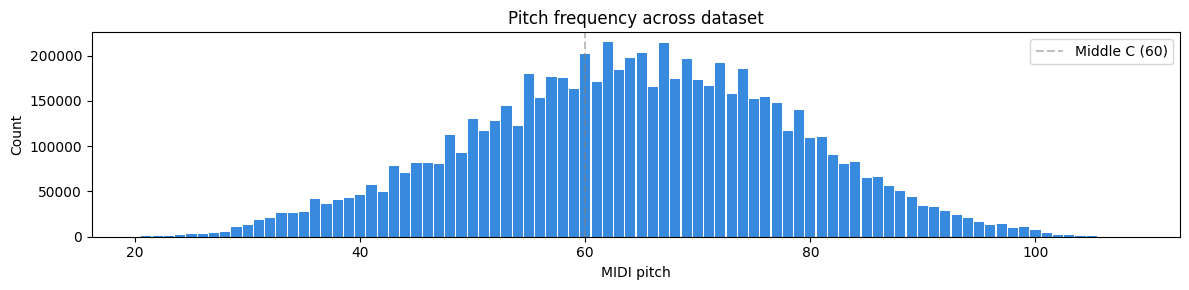

In [6]:
import random
from collections import Counter
import matplotlib.pyplot as plt

pitch_counter = Counter()
for p in token_files:
    ids = json.loads(Path(p).read_text())["ids"]
    for tid in ids:
        name = tokenizer[tid]
        if name.startswith("Pitch_"):
            pitch_counter[int(name.split("_")[1])] += 1

pitches_x = sorted(pitch_counter.keys())
counts    = [pitch_counter[p] for p in pitches_x]

plt.figure(figsize=(12, 3))
plt.bar(pitches_x, counts, color="#378ADD", width=0.9)
plt.axvline(60, color="gray", linestyle="--", alpha=0.5, label="Middle C (60)")
plt.xlabel("MIDI pitch")
plt.ylabel("Count")
plt.title("Pitch frequency across dataset")
plt.legend()
plt.tight_layout()
plt.show()

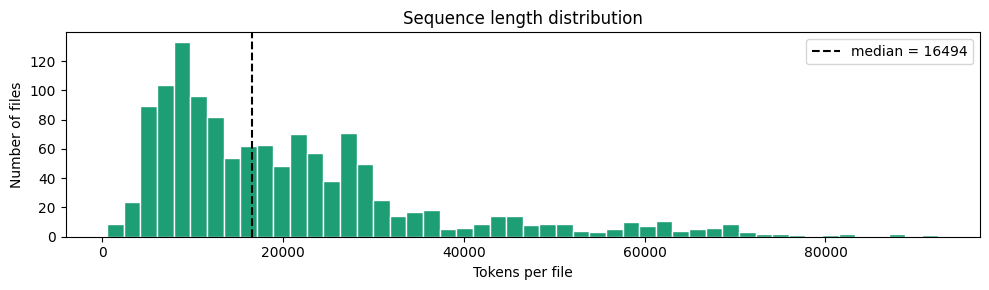

p50: 16494
p90: 43390
p99: 71065


In [7]:
plt.figure(figsize=(10, 3))
plt.hist(lengths, bins=50, color="#1D9E75", edgecolor="white")
plt.axvline(np.median(lengths), color="black", linestyle="--",
            label=f"median = {int(np.median(lengths))}")
plt.xlabel("Tokens per file")
plt.ylabel("Number of files")
plt.title("Sequence length distribution")
plt.legend()
plt.tight_layout()
plt.show()

print(f"p50: {int(np.percentile(lengths, 50))}")
print(f"p90: {int(np.percentile(lengths, 90))}")
print(f"p99: {int(np.percentile(lengths, 99))}")

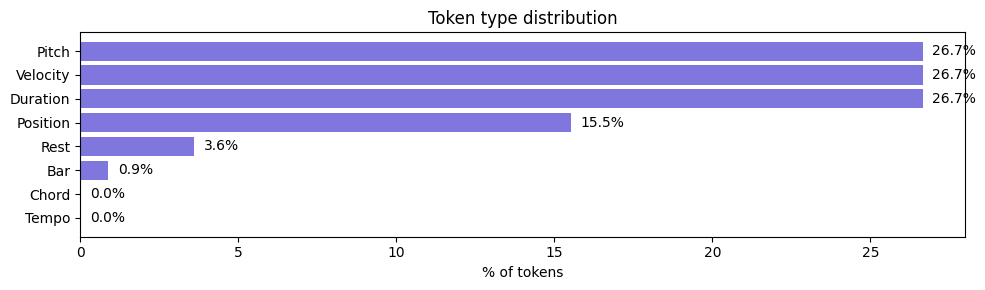

In [8]:
type_counter = Counter()
for p in token_files[:200]:
    ids = json.loads(Path(p).read_text())["ids"]
    for tid in ids:
        type_counter[tokenizer[tid].split("_")[0]] += 1

total = sum(type_counter.values())
types, type_counts = zip(*sorted(type_counter.items(), key=lambda x: -x[1]))
pcts = [100 * c / total for c in type_counts]

plt.figure(figsize=(10, 3))
plt.barh(types, pcts, color="#7F77DD")
for i, (t, pct) in enumerate(zip(types, pcts)):
    plt.text(pct + 0.3, i, f"{pct:.1f}%", va="center", fontsize=10)
plt.xlabel("% of tokens")
plt.title("Token type distribution")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Model — 25M parameter GPT-2

In [9]:
from transformers import GPT2Config, GPT2LMHeadModel

SEQ_LEN    = 1024
VOCAB_SIZE = len(tokenizer)

config = GPT2Config(
    vocab_size   = VOCAB_SIZE,
    n_positions  = SEQ_LEN,
    n_embd       = 512,
    n_layer      = 6,
    n_head       = 8,
    resid_pdrop  = 0.1,
    embd_pdrop   = 0.1,
    attn_pdrop   = 0.1,
    bos_token_id = tokenizer["BOS_None"],
    eos_token_id = tokenizer["EOS_None"],
    pad_token_id = 0,
)

model = GPT2LMHeadModel(config).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters : {n_params/1e6:.1f}M")
print(f"Seq length : {SEQ_LEN}")
print(f"Vocab size : {VOCAB_SIZE}")
print(f"Device     : {DEVICE}")

Parameters : 19.6M
Seq length : 1024
Vocab size : 362
Device     : mps


## 7. Dataset — in-memory sliding windows

**Tune `BATCH_SIZE` for your RAM:**

- 16 GB Mac → `BATCH_SIZE = 2`, `GRAD_ACCUM = 16`
- 24 GB Mac → `BATCH_SIZE = 4`, `GRAD_ACCUM = 8`  (default)
- 36 GB+ Mac → `BATCH_SIZE = 6–8`, `GRAD_ACCUM = 4–6`

Effective batch size stays at 32 regardless.

In [10]:
from torch.utils.data import Dataset, DataLoader, random_split

BATCH_SIZE = 4
STRIDE     = 512

class CachedTokenDataset(Dataset):
    def __init__(self, token_paths, seq_len=1024, stride=512):
        self.seq_len = seq_len
        self.chunks  = []
        for p in tqdm(token_paths, desc="Loading tokens"):
            ids = json.loads(Path(p).read_text())["ids"]
            if len(ids) < seq_len + 1:
                continue
            arr = np.asarray(ids, dtype=np.int32)
            for i in range(0, len(arr) - seq_len - 1, stride):
                self.chunks.append(arr[i : i + seq_len + 1])

    def __len__(self):
        return len(self.chunks)

    def __getitem__(self, idx):
        w = self.chunks[idx]
        return torch.from_numpy(w[:-1]).long(), torch.from_numpy(w[1:]).long()

full = CachedTokenDataset(token_files, seq_len=SEQ_LEN, stride=STRIDE)
print(f"Total windows: {len(full):,}")

n_val = max(1, int(len(full) * 0.05))
train_ds, val_ds = random_split(full, [len(full) - n_val, n_val],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)
print(f"Train: {len(train_ds):,}  |  Val: {len(val_ds):,}")

Loading tokens:   0%|          | 0/1276 [00:00<?, ?it/s]

Total windows: 49,716
Train: 47,231  |  Val: 2,485


## 8. Training loop

Differences from CUDA version:

- No `autocast` / `GradScaler` — MPS doesn't reliably support AMP, runs fp32
- `num_workers=0` in DataLoader — macOS multiprocessing can hang
- Checkpoint every 200 steps — resume cleanly if interrupted
- Auto-resume from `latest.pt` if it exists

In [11]:
import math
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

EPOCHS           = 30
LR               = 3e-4
GRAD_ACCUM       = 8
SAVE_EVERY_STEPS = 200

optimizer   = AdamW(model.parameters(), lr=LR, betas=(0.9, 0.95), weight_decay=0.01)
total_steps = max(1, (len(train_loader) // GRAD_ACCUM) * EPOCHS)
scheduler   = CosineAnnealingLR(optimizer, T_max=total_steps)

start_epoch, best_val, history, step = 0, float("inf"), [], 0

latest = CKPT_DIR / "latest.pt"
if latest.exists():
    ck = torch.load(latest, map_location=DEVICE)
    model.load_state_dict(ck["model"])
    optimizer.load_state_dict(ck["optimizer"])
    scheduler.load_state_dict(ck["scheduler"])
    start_epoch = ck["epoch"]
    history     = ck["history"]
    step        = ck.get("step", 0)
    best_val    = min(h["val"] for h in history) if history else float("inf")
    print(f"Resumed from epoch {start_epoch}, step {step}, best val {best_val:.4f}")

def evaluate():
    model.eval()
    losses = []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            losses.append(model(input_ids=x, labels=y).loss.item())
    model.train()
    return sum(losses) / len(losses)

def save_checkpoint(name, epoch, val_loss=None):
    torch.save({
        "model":     model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "config":    config.to_dict(),
        "epoch":     epoch,
        "step":      step,
        "val_loss":  val_loss,
        "history":   history,
    }, CKPT_DIR / name)

for epoch in range(start_epoch, EPOCHS):
    model.train()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    optimizer.zero_grad()
    running = 0.0

    for i, (x, y) in enumerate(pbar):
        x, y = x.to(DEVICE), y.to(DEVICE)
        loss = model(input_ids=x, labels=y).loss / GRAD_ACCUM
        loss.backward()
        running += loss.item() * GRAD_ACCUM

        if (i + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            step += 1

            if step % SAVE_EVERY_STEPS == 0:
                save_checkpoint("latest.pt", epoch)
                if DEVICE.type == "mps":
                    torch.mps.empty_cache()

            pbar.set_postfix(loss=f"{running/(i+1):.3f}", step=step,
                             lr=f"{scheduler.get_last_lr()[0]:.1e}")

    train_loss = running / len(train_loader)
    val_loss   = evaluate()
    ppl        = math.exp(val_loss)
    history.append({"epoch": epoch+1, "train": train_loss, "val": val_loss, "ppl": ppl})
    print(f"Epoch {epoch+1}: train={train_loss:.4f}  val={val_loss:.4f}  ppl={ppl:.2f}")

    save_checkpoint("latest.pt", epoch + 1, val_loss)
    if val_loss < best_val:
        best_val = val_loss
        save_checkpoint("best.pt", epoch + 1, val_loss)
        print("  -> new best checkpoint")

print(f"\nDone. Best val: {best_val:.4f}  |  ppl: {math.exp(best_val):.2f}")

Resumed from epoch 3, step 4428, best val 2.0523


Epoch 4/30:   0%|          | 0/11808 [00:00<?, ?it/s]

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch 4: train=2.0519  val=1.9615  ppl=7.11
  -> new best checkpoint


Epoch 5/30:   0%|          | 0/11808 [00:00<?, ?it/s]

...

Epoch 28: train=1.5415  val=1.6070  ppl=4.99
  -> new best checkpoint


Epoch 29/30:   0%|          | 0/11808 [00:00<?, ?it/s]

Epoch 29: train=1.5395  val=1.6072  ppl=4.99


Epoch 30/30:   0%|          | 0/11808 [00:00<?, ?it/s]

Epoch 30: train=1.5386  val=1.6071  ppl=4.99

Done. Best val: 1.6070  |  ppl: 4.99


## 9. Training curves

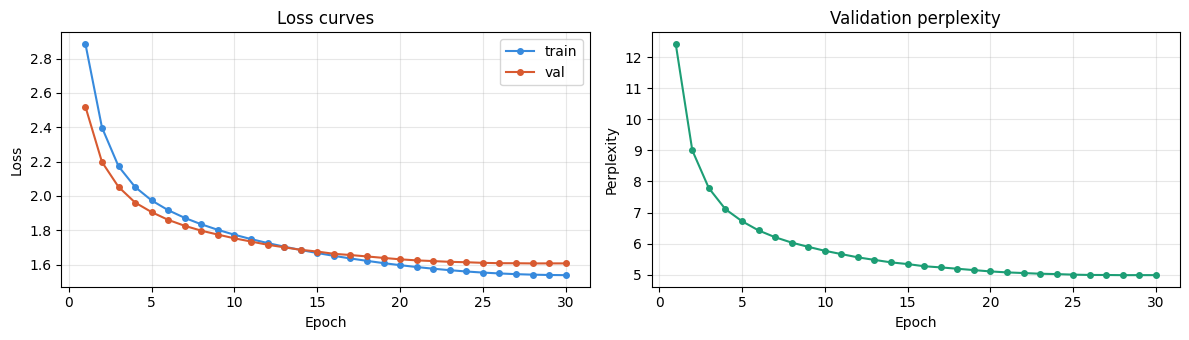

In [12]:
epochs_x   = [h["epoch"] for h in history]
train_loss = [h["train"] for h in history]
val_losses = [h["val"]   for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))
ax1.plot(epochs_x, train_loss, "-o", color="#378ADD", label="train", markersize=4)
ax1.plot(epochs_x, val_losses, "-o", color="#D85A30", label="val",   markersize=4)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.set_title("Loss curves")
ax1.grid(alpha=0.3)

ax2.plot(epochs_x, [h["ppl"] for h in history], "-o", color="#1D9E75", markersize=4)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Perplexity")
ax2.set_title("Validation perplexity")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(SAMPLE_DIR / "training_curves.png", dpi=120)
plt.show()

## 10. Load best checkpoint

In [13]:
ckpt = torch.load(CKPT_DIR / "best.pt", map_location=DEVICE)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"Loaded epoch {ckpt['epoch']}  |  val_loss={ckpt['val_loss']:.4f}  |  ppl={math.exp(ckpt['val_loss']):.2f}")

Loaded epoch 28  |  val_loss=1.6070  |  ppl=4.99


## 11. Direct MIDI builder

Bypasses MidiTok's strict decoder so undertrained models still produce playable output.

In [15]:
from symusic import Score, Track, Note

def tokens_to_midi_direct(ids, tokenizer, tpq=480):
    score = Score(tpq)
    track = Track()
    track.name    = "Piano"
    track.program = 0
    track.is_drum = False

    bar_ticks     = tpq * 4
    current_bar   = 0
    current_pos   = 0
    current_vel   = 64
    pending_pitch = None

    for tid in ids:
        name = tokenizer[tid]
        typ  = name.split("_", 1)[0]
        val  = name.split("_", 1)[1] if "_" in name else ""

        if typ == "Bar":
            current_bar += 1
            current_pos  = 0
        elif typ == "Position":
            try:
                current_pos = int(int(val) * tpq / 8)
            except ValueError:
                pass
        elif typ == "Velocity":
            try:
                current_vel = min(127, max(1, int(val)))
            except ValueError:
                pass
        elif typ == "Pitch":
            try:
                pending_pitch = int(val)
            except ValueError:
                pending_pitch = None
        elif typ == "Duration" and pending_pitch is not None:
            try:
                parts = val.split(".")
                whole, num, denom = int(parts[0]), int(parts[1]), int(parts[2])
                dur_ticks = max(int((whole + num/denom) * tpq), tpq // 16)
            except (ValueError, IndexError):
                dur_ticks = tpq // 2
            start = max(0, (current_bar - 1) * bar_ticks + current_pos)
            track.notes.append(Note(start, dur_ticks, pending_pitch, current_vel))
            pending_pitch = None

    score.tracks.append(track)
    return score

## 12. Generate a sample

In [34]:
model.eval()
prompt = torch.tensor([[tokenizer["BOS_None"], tokenizer["Bar_None"]]]).to(DEVICE)

with torch.no_grad():
    output = model.generate(
        prompt,
        max_new_tokens     = model.config.n_positions - 3,
        do_sample          = True,
        temperature        = 0.9,
        top_p              = 0.9,
        top_k              = 40,
        repetition_penalty = 1.05,
        pad_token_id       = model.config.pad_token_id,
    )

generated_ids = output[0].cpu().tolist()
print(f"Generated {len(generated_ids)} tokens")

score = tokens_to_midi_direct(generated_ids, tokenizer)
print(f"Tracks: {len(score.tracks)}, Notes: {len(score.tracks[0].notes)}")

score.dump_midi(str(SAMPLE_DIR / "generated.mid"))
print(f"Saved to {SAMPLE_DIR / 'generated.mid'}")

Generated 1023 tokens
Tracks: 1, Notes: 251
Saved to /Users/shantanusharma/Desktop/Project/samples/generated.mid


## 13. Piano roll visualization

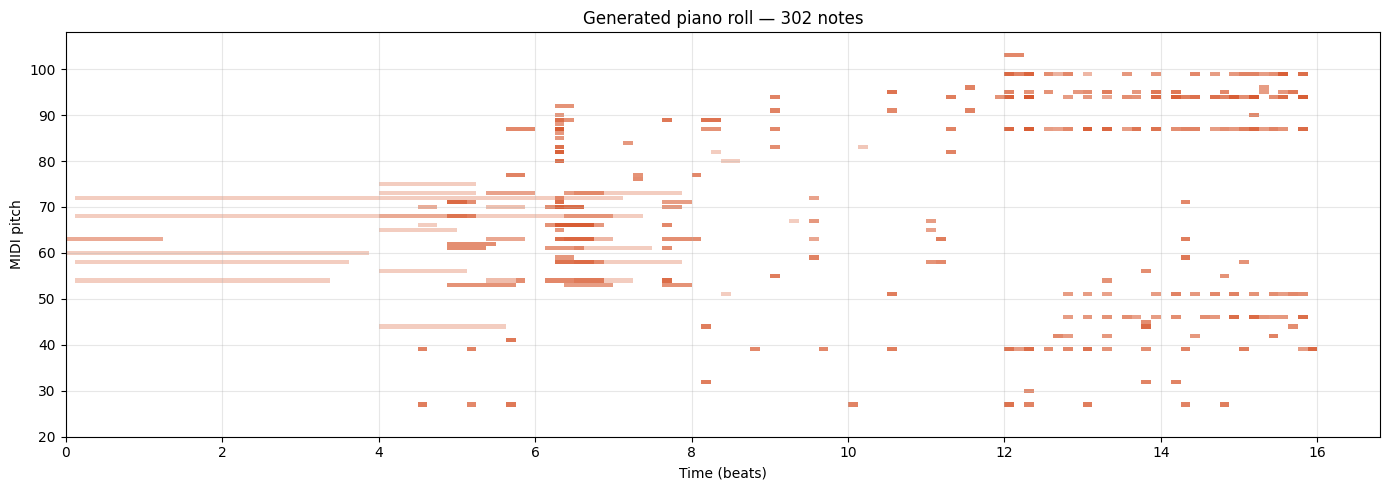

In [19]:
notes = score.tracks[0].notes
fig, ax = plt.subplots(figsize=(14, 5))
for n in notes:
    start_s = n.time / score.tpq
    dur_s   = max(n.duration / score.tpq, 0.05)
    ax.barh(n.pitch, dur_s, left=start_s, height=0.9,
            color="#D85A30", alpha=max(0.3, n.velocity / 127), edgecolor="none")
ax.set_xlabel("Time (beats)")
ax.set_ylabel("MIDI pitch")
ax.set_ylim(20, 108)
ax.set_title(f"Generated piano roll — {len(notes)} notes")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SAMPLE_DIR / "generated_piano_roll.png", dpi=120)
plt.show()

## 14. Audio playback

Requires FluidSynth and a SoundFont. If you haven't set these up:

```bash
brew install fluidsynth
mkdir -p ~/soundfonts
curl -L -o ~/soundfonts/FluidR3_GM.sf2 \
  https://ftp.osuosl.org/pub/musescore-soundfonts/FluidR3_GM.sf2
```

In [20]:
from midi2audio import FluidSynth
from IPython.display import Audio, display, HTML

SF2 = None
for candidate in [
    Path.home() / "soundfonts" / "FluidR3_GM.sf2",
    Path("/opt/homebrew/share/sounds/sf2/FluidR3_GM.sf2"),
    Path("/usr/local/share/sounds/sf2/FluidR3_GM.sf2"),
    Path("/Library/Audio/Sounds/Banks/FluidR3_GM.sf2"),
]:
    if candidate.exists():
        SF2 = str(candidate)
        break

if SF2 is None:
    raise FileNotFoundError(
        "No SoundFont found. See the markdown cell above for download instructions."
    )

print(f"Using SoundFont: {SF2}")
fs = FluidSynth(SF2)

fs.midi_to_audio(str(SAMPLE_DIR / "generated.mid"), str(SAMPLE_DIR / "generated.wav"))
display(Audio(str(SAMPLE_DIR / "generated.wav")))

Using SoundFont: /Users/shantanusharma/soundfonts/FluidR3_GM.sf2


fluidsynth: error: fluid_is_soundfont(): expected RIFF chunk id '0x46464952' but got '0x4F44213C'.
Parameter '/Users/shantanusharma/soundfonts/FluidR3_GM.sf2' not a SoundFont or MIDI file or error occurred identifying it.
error: '-F' is an illegal option at this place, only -b option is allowed here.
fluidsynth: error: fluid_is_soundfont(): fopen() failed: 'File does not exist.'
Parameter '/Users/shantanusharma/Desktop/Project/samples/generated.wav' not a SoundFont or MIDI file or error occurred identifying it.
error: '-r' is an illegal option at this place, only -b option is allowed here.
fluidsynth: error: fluid_is_soundfont(): fopen() failed: 'File does not exist.'
Parameter '44100' not a SoundFont or MIDI file or error occurred identifying it.
fluidsynth: warning: No preset found on channel 0 [bank=0 prog=0]


FluidSynth runtime version 2.5.4
Copyright (C) 2000-2026 Peter Hanappe and others.
Distributed under the LGPL license.
SoundFont(R) is a registered trademark of Creative Technology Ltd.



ValueError: rate must be specified when data is a numpy array or list of audio samples.

## 15. Multiple samples at different temperatures

In [ ]:
model.eval()
prompt = torch.tensor([[tokenizer["BOS_None"], tokenizer["Bar_None"]]]).to(DEVICE)

for i, temp in enumerate([0.7, 0.9, 1.1]):
    with torch.no_grad():
        output = model.generate(
            prompt,
            max_new_tokens     = model.config.n_positions - 3,
            do_sample          = True,
            temperature        = temp,
            top_p              = 0.9,
            top_k              = 40,
            repetition_penalty = 1.05,
            pad_token_id       = model.config.pad_token_id,
        )
    ids = output[0].cpu().tolist()
    s   = tokens_to_midi_direct(ids, tokenizer)

    midi_path = SAMPLE_DIR / f"sample_{i+1}_temp{temp}.mid"
    wav_path  = SAMPLE_DIR / f"sample_{i+1}_temp{temp}.wav"
    s.dump_midi(str(midi_path))
    fs.midi_to_audio(str(midi_path), str(wav_path))

    display(HTML(f"<h4>Sample {i+1} — temperature {temp} — {len(s.tracks[0].notes)} notes</h4>"))
    display(Audio(str(wav_path)))

## 16. Evaluation — held-out perplexity

In [21]:
total_loss, total_tokens = 0.0, 0
model.eval()
with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        out  = model(input_ids=x, labels=y)
        n    = y.numel()
        total_loss   += out.loss.item() * n
        total_tokens += n

val_loss   = total_loss / total_tokens
perplexity = math.exp(val_loss)
print(f"Held-out cross-entropy: {val_loss:.4f}")
print(f"Perplexity:             {perplexity:.2f}")
print(f"Random baseline PPL:    {len(tokenizer):.0f}")
print(f"Improvement:            {len(tokenizer)/perplexity:.1f}x over random")

Held-out cross-entropy: 1.6074
Perplexity:             4.99
Random baseline PPL:    362
Improvement:            72.6x over random


## 17. Grammar validity

In [ ]:
def grammar_validity(ids, tokenizer):
    valid_after = {
        "Bar":      {"Position", "Bar", "EOS"},
        "Position": {"Velocity", "Chord", "Pitch"},
        "Velocity": {"Pitch"},
        "Pitch":    {"Duration"},
        "Duration": {"Pitch", "Velocity", "Position", "Bar", "Rest", "EOS"},
        "Rest":     {"Position", "Bar"},
        "Chord":    {"Position", "Pitch", "Velocity"},
        "BOS":      {"Bar", "Position"},
    }
    valid, total = 0, 0
    for i in range(len(ids) - 1):
        curr = tokenizer[ids[i]].split("_")[0]
        nxt  = tokenizer[ids[i+1]].split("_")[0]
        if curr in valid_after:
            total += 1
            if nxt in valid_after[curr]:
                valid += 1
    return valid / max(total, 1)

validity = grammar_validity(generated_ids, tokenizer)
print(f"Grammar validity (generated): {validity*100:.1f}%")

real_validity = []
for p in random.sample(token_files, 20):
    ids = json.loads(Path(p).read_text())["ids"]
    real_validity.append(grammar_validity(ids, tokenizer))
print(f"Grammar validity (real data): {np.mean(real_validity)*100:.1f}%")

## 18. Music-theoretic metrics

In [22]:
def extract_note_features(score):
    if not score.tracks or not score.tracks[0].notes:
        return None
    notes = score.tracks[0].notes
    return {
        "pitches":    np.array([n.pitch for n in notes]),
        "velocities": np.array([n.velocity for n in notes]),
        "durations":  np.array([n.duration / score.tpq for n in notes]),
        "onsets":     np.array([n.time / score.tpq for n in notes]),
    }

def pitch_class_histogram(pitches):
    hist = np.bincount(pitches % 12, minlength=12).astype(float)
    return hist / (hist.sum() + 1e-9)

def compute_metrics(score):
    f = extract_note_features(score)
    if f is None:
        return None
    onsets = f["onsets"]
    return {
        "n_notes":      len(f["pitches"]),
        "pitch_range":  int(f["pitches"].max() - f["pitches"].min()),
        "pitch_count":  len(np.unique(f["pitches"])),
        "avg_interval": float(np.mean(np.abs(np.diff(f["pitches"])))) if len(f["pitches"]) >= 2 else 0.0,
        "note_density": len(onsets) / (onsets.max() - onsets.min() + 1e-9),
        "avg_duration": float(f["durations"].mean()),
        "avg_velocity": float(f["velocities"].mean()),
        "ioi":          float(np.mean(np.diff(np.sort(onsets)))) if len(onsets) >= 2 else 0.0,
        "pc_histogram": pitch_class_histogram(f["pitches"]),
    }

gen_metrics = compute_metrics(score)
print("Generated piece:")
for k, v in gen_metrics.items():
    if k != "pc_histogram":
        print(f"  {k:15s} {v:.3f}")

Generated piece:
  n_notes         302.000
  pitch_range     76.000
  pitch_count     48.000
  avg_interval    18.173
  note_density    19.024
  avg_duration    0.288
  avg_velocity    80.368
  ioi             0.053


In [23]:
real_metrics = []
for p in tqdm(random.sample(token_files, min(50, len(token_files))), desc="Analyzing real"):
    ids = json.loads(Path(p).read_text())["ids"][:500]
    try:
        s = tokens_to_midi_direct(ids, tokenizer)
        m = compute_metrics(s)
        if m is not None:
            real_metrics.append(m)
    except Exception:
        continue

print(f"Analyzed {len(real_metrics)} real pieces\n")

numeric_keys = ["n_notes", "pitch_range", "pitch_count", "avg_interval",
                "note_density", "avg_duration", "avg_velocity", "ioi"]

print(f"{'Metric':<16}{'Real mean+/-std':<22}{'Generated':<14}{'z':<8}")
print("-" * 62)
for k in numeric_keys:
    real_vals = np.array([m[k] for m in real_metrics])
    mu, sigma = real_vals.mean(), real_vals.std() + 1e-9
    z = (gen_metrics[k] - mu) / sigma
    print(f"{k:<16}{mu:>8.3f} +/- {sigma:<8.3f}   {gen_metrics[k]:<12.3f}  {z:+.2f}")

Analyzing real:   0%|          | 0/50 [00:00<?, ?it/s]

Analyzed 50 real pieces

Metric          Real mean+/-std       Generated     z       
--------------------------------------------------------------
n_notes          128.880 +/- 6.352      302.000       +27.26
pitch_range       45.960 +/- 10.305     76.000        +2.92
pitch_count       28.500 +/- 7.106      48.000        +2.74
avg_interval      10.027 +/- 2.400      18.173        +3.39
note_density       7.485 +/- 4.354      19.024        +2.65
avg_duration       0.572 +/- 0.423      0.288         -0.67
avg_velocity      59.803 +/- 9.964      80.368        +2.06
ioi                0.196 +/- 0.127      0.053         -1.13


## 19. Pitch class distribution

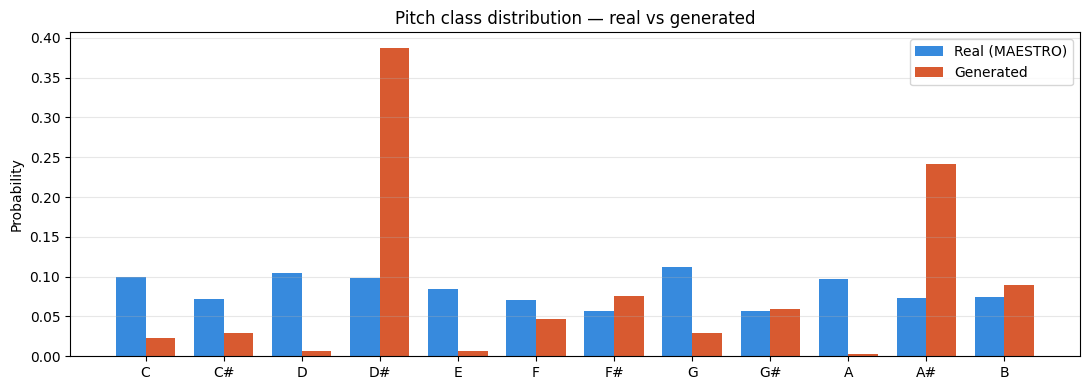

KL divergence (gen || real): 0.6979
  KL < 0.1: excellent tonal match
  KL 0.1-0.3: good
  KL > 0.5: weak


In [24]:
from scipy.stats import entropy

note_names = ["C","C#","D","D#","E","F","F#","G","G#","A","A#","B"]

real_pc = np.mean([m["pc_histogram"] for m in real_metrics], axis=0)
gen_pc  = gen_metrics["pc_histogram"]

x = np.arange(12)
w = 0.38
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - w/2, real_pc, w, label="Real (MAESTRO)", color="#378ADD")
ax.bar(x + w/2, gen_pc,  w, label="Generated",       color="#D85A30")
ax.set_xticks(x)
ax.set_xticklabels(note_names)
ax.set_ylabel("Probability")
ax.legend()
ax.grid(alpha=0.3, axis="y")
ax.set_title("Pitch class distribution — real vs generated")
plt.tight_layout()
plt.savefig(SAMPLE_DIR / "pc_histogram.png", dpi=120)
plt.show()

kl = entropy(gen_pc + 1e-9, real_pc + 1e-9)
print(f"KL divergence (gen || real): {kl:.4f}")
print(f"  KL < 0.1: excellent tonal match")
print(f"  KL 0.1-0.3: good")
print(f"  KL > 0.5: weak")

## 20. Memorization check (n-gram overlap)

In [25]:
def ngram_overlap(gen_ids, ref_ids_list, n=8):
    gen_grams = set(tuple(gen_ids[i:i+n]) for i in range(len(gen_ids)-n+1))
    ref_grams = set()
    for ref in ref_ids_list:
        for i in range(len(ref)-n+1):
            ref_grams.add(tuple(ref[i:i+n]))
    return len(gen_grams & ref_grams) / max(len(gen_grams), 1)

sample_refs = [json.loads(Path(p).read_text())["ids"] for p in random.sample(token_files, 100)]

for n in [4, 8, 16]:
    overlap = ngram_overlap(generated_ids, sample_refs, n=n)
    print(f"{n}-gram overlap with training set: {overlap*100:.1f}%")

print("\nHealthy: high at n=4, moderate at n=8, low at n=16.")
print("n=16 overlap > 20% suggests memorization.")

4-gram overlap with training set: 0.0%
8-gram overlap with training set: 0.0%
16-gram overlap with training set: 0.0%

Healthy: high at n=4, moderate at n=8, low at n=16.
n=16 overlap > 20% suggests memorization.


## 21. Final summary

In [26]:
print("=" * 54)
print("FINAL EVALUATION SUMMARY")
print("=" * 54)
print(f"Model          : {sum(p.numel() for p in model.parameters())/1e6:.1f}M params")
print(f"Epochs trained : {len(history)}")
print(f"Best val loss  : {ckpt['val_loss']:.4f}")
print(f"Perplexity     : {math.exp(ckpt['val_loss']):.2f}")
print(f"\nGenerated      : {gen_metrics['n_notes']} notes")
print(f"Grammar valid  : {validity*100:.1f}%  (real: {np.mean(real_validity)*100:.1f}%)")
print(f"Pitch-class KL : {kl:.4f}")

z_scores = [abs((gen_metrics[k] - np.mean([m[k] for m in real_metrics])) /
                (np.std([m[k] for m in real_metrics]) + 1e-9)) for k in numeric_keys]
print(f"Mean |z-score| : {np.mean(z_scores):.2f}")
print(f"\nAll samples saved to: {SAMPLE_DIR}")

FINAL EVALUATION SUMMARY
Model          : 19.6M params
Epochs trained : 30
Best val loss  : 1.6070
Perplexity     : 4.99

Generated      : 302 notes


NameError: name 'validity' is not defined